In [1]:
import sys,os,glob,copy
sys.path.append('../')
import numpy as np
from numpy.linalg import norm
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.interpolate import LinearNDInterpolator,interp2d, griddata
from itertools import product
import matplotlib as mpl
from matplotlib.colors import LogNorm
from IPython.display import display, Markdown
import glob

defaultPars = {'figure.figsize': (5, 4), 'lines.markersize' : 4, 'axes.titlesize' : 13, 'font.size' : 13,
               'axes.labelsize' : 16, 'xtick.labelsize' : 13, 'ytick.labelsize' : 13, 'legend.fontsize' : 10,
               "text.usetex": True, "font.family": "sans-serif", "font.sans-serif": ["Helvetica"],
               'font.family':'Times New Roman', 'font.serif':'Times New Roman', "savefig.dpi" : 300,
               'contour.linewidth' : 2.0, 'lines.linewidth' : 2.0, 'axes.grid' : True,
               'grid.linewidth' : 0.5, 'grid.color' : 'lightgray', 'axes.axisbelow' : True
               }
plt.rcParams.update(defaultPars) #Figure resolution
pd.set_option('display.max_rows', 200)

In [2]:
cmsCutflow = pd.read_pickle('../../CMS-EXO-20-004/AuxInfo/CMS-EXO-20-004-data/DMsimp_S3D_uR_CF_Monojet.pcl')

In [3]:
cutflow = pd.read_pickle('../../CMS-EXO-20-004/scanResults_S3D_uR_CMS_BPs_nocut.pcl')

In [4]:
cutflow.T

,0,1,2,3,4,5,6,7,8,9,...,134,135,136,137,138,139,140,141,142,143
Coupling,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,...,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel
Mode,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,...,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets
$m_{med}$,100.0,100.0,100.0,100.0,100.0,100.0,300.0,300.0,300.0,300.0,...,2000.0,2200.0,2200.0,2200.0,2200.0,2200.0,2200.0,2200.0,2200.0,2200.0
$m_{DM}$,1.0,1.0,1.0,75.0,75.0,75.0,1.0,1.0,1.0,200.0,...,500.0,1.0,1.0,1.0,200.0,200.0,200.0,350.0,350.0,350.0
Data-takingperiod,2018,2017,2016,2018,2017,2016,2018,2017,2016,2018,...,2016,2018,2017,2016,2018,2017,2016,2018,2017,2016
Luminosity (1/fb),59.7,41.5,36.0,59.7,41.5,36.0,59.7,41.5,36.0,59.7,...,36.0,59.7,41.5,36.0,59.7,41.5,36.0,59.7,41.5,36.0
bin_250.0_280.0,46266.668603,37867.065077,34631.152243,5150.802576,4234.243721,3704.963256,17593.189837,15866.755321,12961.960737,3635.053579,...,1.671162,4.186461,3.881873,3.052358,3.234783,2.931047,2.591876,2.457609,1.990369,1.850565
bin_250.0_280.0_ErrorPlus,1784.775489,1614.65708,1544.126759,182.336435,165.319443,154.642178,694.347818,659.399848,595.99159,120.900084,...,0.083979,0.164714,0.158609,0.140645,0.128166,0.12181,0.114546,0.095088,0.085573,0.082513
bin_250.0_280.0_ErrorMinus,1784.775489,1614.65708,1544.126759,182.336435,165.319443,154.642178,694.347818,659.399848,595.99159,120.900084,...,0.083979,0.164714,0.158609,0.140645,0.128166,0.12181,0.114546,0.095088,0.085573,0.082513
bin_280.0_310.0,29536.31076,25267.659788,25405.358206,3621.052939,3085.317834,2646.402326,10879.277828,8440.346526,8440.346526,2609.678952,...,1.502357,3.596727,2.864421,2.430221,2.900674,2.500755,2.252705,2.012444,1.758589,1.475301


In [5]:
pd.read_pickle('../../DMSimp_S3D_uR_2j-full_CMS_BPs/Events/run_01/ys3u1_100_1_cms_exo_20_004.pcl').T

,0,1,2
Data-takingperiod,2016,2017,2018
Luminosity (1/fb),36.0,41.5,59.7
bin_250.0_280.0,22151.078321,39871.940978,31011.509649
bin_250.0_280.0_ErrorPlus,7004.786012,9397.906615,8288.174582
bin_250.0_280.0_ErrorMinus,7004.786012,9397.906615,8288.174582
bin_280.0_310.0,17720.862657,15505.754825,19935.970489
bin_280.0_310.0_ErrorPlus,6265.271077,5860.624451,6645.323496
bin_280.0_310.0_ErrorMinus,6265.271077,5860.624451,6645.323496
bin_310.0_340.0,6645.323496,8860.431328,8860.431328
bin_310.0_340.0_ErrorPlus,3836.679309,4430.215664,4430.215664


In [12]:
cmsCutflow[(cmsCutflow['$m_{DM}$']==550)&(cmsCutflow['$m_{med}$']==750)].T

,76,100,135,164
$m_{med}$,750.0,750.0,750.0,750.0
$m_{DM}$,550.0,550.0,550.0,550.0
$\lambda$,1.0,1.0,1.0,1.0
Mode,DM+2QCDjets,DM+QCDjets,DM+2QCDjets,DM+QCDjets
Data-takingperiod,2018,2018,2017,2017
Fullsample,1.0,1.0,1.0,1.0
Triggeremulation,0.76326,0.83574,0.7745,0.84237
$p_{T}^{miss}>250$GeV,0.4081,0.47696,0.40654,0.47943
$p_{T}^{miss}$qualityfilters,0.40727,0.47642,0.40569,0.47858
Electronveto,0.40587,0.47349,0.40422,0.4753


In [6]:
year = 2017

cutflow = cutflow[cutflow['Data-takingperiod']==year]
cmsCutflow = cmsCutflow[cmsCutflow['Data-takingperiod']==year]

In [7]:
models = []
mCols = ['Mode','$m_{med}$','$m_{DM}$','$\lambda$','Data-takingperiod']
for row in cutflow[mCols].values:
    m = dict(zip(mCols,row.tolist()))
    if m not in models:
        models.append(m)
print('%i models loaded' %len(models))

48 models loaded


In [8]:
parameters = {label : list(set([m[label] for m in models])) for label in mCols}
for k,v in parameters.items():
    if len(v) == 1:
        parameters[k] = v[0]
print(parameters)

textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in parameters.items() if k not in ['$m_{med}$','$m_{DM}$']])
print(textstr)

{'Mode': 'DM+QCDjets', '$m_{med}$': [1600.0, 100.0, 1000.0, 1800.0, 300.0, 750.0, 1200.0, 2000.0, 500.0, 1400.0, 2200.0], '$m_{DM}$': [800.0, 1.0, 900.0, 550.0, 200.0, 650.0, 75.0, 750.0, 400.0, 500.0, 600.0, 700.0, 350.0], '$\\lambda$': 1.0, 'Data-takingperiod': 2017}
Mode = DM+QCDjets
$\lambda$ = 1.0
Data-takingperiod = 2017


In [9]:
keys = list(cmsCutflow[mCols].columns.values)
i1 = cutflow.set_index(keys).index
i2 = cmsCutflow.set_index(keys).index
cutflow = cutflow[i1.isin(i2)]
cmsCutflow = cmsCutflow[i2.isin(i1)]
print(len(cutflow),len(cmsCutflow))

46 46


In [10]:
cutflow.sort_values(['$m_{med}$','$m_{DM}$'],inplace=True,
                ascending=[True,True],ignore_index=True)  
cmsCutflow.sort_values(['$m_{med}$','$m_{DM}$'],inplace=True,
                ascending=[True,True],ignore_index=True)

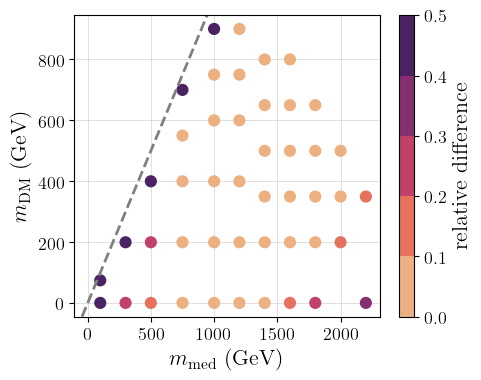

In [12]:
mmed = cutflow['$m_{med}$']
mDM = cutflow['$m_{DM}$']

relDiff = np.abs(cmsCutflow['HCALmitigation($\\phi^{miss}$)'] - cutflow['HCALmitigation($\\phi^{miss}$)'])/np.array(cmsCutflow['HCALmitigation($\\phi^{miss}$)'])

plt.scatter(x=mmed, y=mDM, c=relDiff, cmap=plt.get_cmap('flare', 5), vmin=0., vmax=0.5, s=60)
cbar = plt.colorbar(label=r'relative difference')
cbar.set_ticks([0.,0.1,0.2,0.3,0.4,0.5])
plt.axline((1, 1), slope=1, linestyle='--', color='gray')

plt.xlabel(r'$m_{\rm med}$ (GeV)')
plt.ylabel(r'$m_{\rm DM}$ (GeV)')

plt.tight_layout()


plt.show()

In [39]:
cutflow[(cutflow['$m_{med}$']==1000)&(cutflow['$m_{DM}$']==900)].T

,17
Coupling,tchannel
Mode,DM+QCDjets
$m_{med}$,1000.0
$m_{DM}$,900.0
Data-takingperiod,2017
Luminosity (1/fb),41.5
bin_250.0_280.0,7.086368
bin_250.0_280.0_ErrorPlus,0.254059
bin_250.0_280.0_ErrorMinus,0.254059
bin_280.0_310.0,6.02068


In [41]:
cmsCutflow[(cutflow['$m_{med}$']==100)&(cutflow['$m_{DM}$']==1)].T

,0
$m_{med}$,100.0
$m_{DM}$,1.0
$\lambda$,1.0
Mode,DM+QCDjets
Data-takingperiod,2017
Fullsample,1.0
Triggeremulation,0.047334
$p_{T}^{miss}>250$GeV,0.003092
$p_{T}^{miss}$qualityfilters,0.003092
Electronveto,0.003073


In [18]:
cutflow[(cutflow['$m_{med}$']==1800)&(cutflow['$m_{DM}$']==1)].T

,36
Coupling,tchannel
Mode,DM+QCDjets
$m_{med}$,1800.0
$m_{DM}$,1.0
Data-takingperiod,2017
Luminosity (1/fb),41.5
bin_250.0_280.0,7.812074
bin_250.0_280.0_ErrorPlus,0.36424
bin_250.0_280.0_ErrorMinus,0.36424
bin_280.0_310.0,6.470435
